In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import nibabel as nib
import cv2
import pandas as pd
from scipy.ndimage import label as scipy_label
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────
# VIEW CONFIG  (label counts come directly from the challenge)
# ─────────────────────────────────────────────────────────────
VIEW_CONFIG = {
    #  view       num_fg  total(+bg)  lv_cavity_label
    "SAX_TR": {"num_classes": 4, "lv_label": 2},   # 0=bg,1=LV-myo,2=LV-cav,3=RV-cav
    "2CH_TR": {"num_classes": 3, "lv_label": 1},   # 0=bg,1=LV-cav,2=LV-myo
    "4CH_TR": {"num_classes": 6, "lv_label": 1},   # 0=bg,1=LV-cav,2=LV-myo,3=RV-cav,4=RA,5=LA
}


# ─────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):
        super().__init__()
        self.d1, self.p1 = DoubleConv(in_channels, 64),  nn.MaxPool2d(2)
        self.d2, self.p2 = DoubleConv(64, 128),           nn.MaxPool2d(2)
        self.d3, self.p3 = DoubleConv(128, 256),          nn.MaxPool2d(2)
        self.d4, self.p4 = DoubleConv(256, 512),          nn.MaxPool2d(2)
        self.bn          = DoubleConv(512, 1024)

        self.u4 = nn.ConvTranspose2d(1024, 512, 2, stride=2); self.c4 = DoubleConv(1024, 512)
        self.u3 = nn.ConvTranspose2d(512,  256, 2, stride=2); self.c3 = DoubleConv(512,  256)
        self.u2 = nn.ConvTranspose2d(256,  128, 2, stride=2); self.c2 = DoubleConv(256,  128)
        self.u1 = nn.ConvTranspose2d(128,   64, 2, stride=2); self.c1 = DoubleConv(128,   64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.d1(x);          d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2)); d4 = self.d4(self.p3(d3))
        bn = self.bn(self.p4(d4))
        x = self.c4(torch.cat([self.u4(bn), d4], 1))
        x = self.c3(torch.cat([self.u3(x),  d3], 1))
        x = self.c2(torch.cat([self.u2(x),  d2], 1))
        x = self.c1(torch.cat([self.u1(x),  d1], 1))
        return self.final(x)


# ─────────────────────────────────────────────────────────────
# LOSS
# ─────────────────────────────────────────────────────────────
class DiceCELoss(nn.Module):
    def __init__(self, num_classes, ce_w=0.5, dice_w=0.5, smooth=1e-5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ce_w = ce_w; self.dice_w = dice_w

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        probs   = F.softmax(logits, dim=1)
        t_oh    = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dice = 0.0
        for c in range(1, self.num_classes):
            p = probs[:, c]; t = t_oh[:, c]
            dice += 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.ce_w * ce_loss + self.dice_w * dice / (self.num_classes - 1)


# ─────────────────────────────────────────────────────────────
# DATASET  — loads real LVEF from dataset.xlsx for SAX
# ─────────────────────────────────────────────────────────────
class CineMRIDataset(Dataset):
    def __init__(self, root_dir, view="SAX_TR", img_size=256, augment=False):
        self.img_dir  = os.path.join(root_dir, view, "image")
        self.mask_dir = os.path.join(root_dir, view, "anno")
        self.img_size = img_size
        self.augment  = augment
        self.view     = view

        # ── Load real LVEF from Excel (SAX only) ──────────────
        # Key fix: EF ground truth lives in dataset.xlsx, not in pixel counts
        self.lvef_map = {}   # {filename_stem: lvef_value}
        xlsx_path = os.path.join(root_dir, "dataset.xlsx")
        sheet_map = {"SAX_TR": "SAX", "2CH_TR": "2CH", "4CH_TR": "4CH"}
        if os.path.exists(xlsx_path) and view in sheet_map:
            try:
                df = pd.read_excel(xlsx_path, sheet_name=sheet_map[view])
                if "LVEF" in df.columns and "image_path" in df.columns:
                    for _, row in df.iterrows():
                        stem = os.path.splitext(os.path.basename(str(row["image_path"])))[0]
                        stem = stem.replace(".nii", "")   # handle .nii.gz
                        self.lvef_map[stem] = float(row["LVEF"])
            except Exception as e:
                print(f"[WARN] Could not load LVEF from xlsx: {e}")

        # ── Build sample list ──────────────────────────────────
        self.files   = sorted(os.listdir(self.img_dir))
        self.samples = []   # (img_path, mask_path, t, s_or_None, lvef_or_nan)

        for file in self.files:
            img_path  = os.path.join(self.img_dir,  file)
            mask_path = os.path.join(self.mask_dir, file)
            stem      = file.replace(".nii.gz", "").replace(".nii", "")
            lvef      = self.lvef_map.get(stem, float("nan"))

            img = nib.load(img_path).get_fdata()
            if img.ndim == 4:
                H, W, T, S = img.shape
                for s in range(S):
                    for t in range(T):
                        self.samples.append((img_path, mask_path, t, s, lvef))
            elif img.ndim == 3:
                H, W, T = img.shape
                for t in range(T):
                    self.samples.append((img_path, mask_path, t, None, lvef))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, t, s, lvef = self.samples[idx]

        img  = nib.load(img_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()

        if img.ndim == 4:
            img  = img[:, :, t, s]
            mask = mask[:, :, t, s]
        else:
            img  = img[:, :, t]
            mask = mask[:, :, t]

        img = (img - img.mean()) / (img.std() + 1e-8)
        img  = cv2.resize(img,  (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        if self.augment:
            img, mask = self._augment(img, mask)

        img  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.long)
        return img, mask, torch.tensor(lvef, dtype=torch.float32)

    def _augment(self, img, mask):
        if np.random.rand() > 0.5:
            img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if np.random.rand() > 0.5:
            img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        k = np.random.randint(0, 4)
        img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()
        alpha = np.random.uniform(0.8, 1.2)
        beta  = np.random.uniform(-0.1, 0.1)
        img   = np.clip(alpha * img + beta, img.min(), img.max())
        return img, mask


# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────
def dice_score(preds, targets, num_classes):
    preds = torch.argmax(preds, dim=1)
    dice  = 0.0
    for c in range(1, num_classes):
        p = (preds   == c).float()
        t = (targets == c).float()
        dice += (2*(p*t).sum() + 1e-5) / (p.sum() + t.sum() + 1e-5)
    return dice / (num_classes - 1)


def hausdorff95_asd(pred_np, gt_np, num_classes):
    """2D per-sample HD95 and ASD, averaged over foreground classes."""
    hds, asds = [], []
    for c in range(1, num_classes):
        p = (pred_np == c); t = (gt_np == c)
        if p.sum() == 0 or t.sum() == 0:
            continue
        # Surface points via erosion
        from scipy.ndimage import binary_erosion
        p_surf = np.column_stack(np.where(p & ~binary_erosion(p)))
        t_surf = np.column_stack(np.where(t & ~binary_erosion(t)))
        if len(p_surf) == 0 or len(t_surf) == 0:
            continue
        D = cdist(p_surf, t_surf)
        d_pt = D.min(axis=1); d_tp = D.min(axis=0)
        hds.append(max(np.percentile(d_pt, 95), np.percentile(d_tp, 95)))
        asds.append((d_pt.mean() + d_tp.mean()) / 2.0)
    return (np.mean(hds), np.mean(asds)) if hds else (float("nan"), float("nan"))


def keep_largest_component(pred, num_classes):
    clean = np.zeros_like(pred)
    for c in range(1, num_classes):
        binary = (pred == c)
        labeled, n = scipy_label(binary)
        if n == 0: continue
        largest = np.argmax([(labeled == i).sum() for i in range(1, n+1)]) + 1
        clean[labeled == largest] = c
    return clean


def estimate_lv_pixels(pred_np, lv_label):
    """Count LV cavity pixels — used to estimate ED/ES volumes for EF."""
    return float((pred_np == lv_label).sum())


# ─────────────────────────────────────────────────────────────
# TRAINING  (per-view, single script)
# ─────────────────────────────────────────────────────────────
def train_view(root_dir, view="SAX_TR", num_epochs=15, batch_size=32, lr=1e-4, img_size=256):
    cfg         = VIEW_CONFIG[view]
    num_classes = cfg["num_classes"]
    lv_label    = cfg["lv_label"]

    print(f"\n{'='*60}")
    print(f"  Training on view: {view}  |  num_classes: {num_classes}  |  LV label: {lv_label}")
    print(f"{'='*60}")

    # ── Datasets ──────────────────────────────────────────────
    train_ds = CineMRIDataset(root_dir, view=view, img_size=img_size, augment=True)
    val_ds   = CineMRIDataset(root_dir, view=view, img_size=img_size, augment=False)

    indices = list(range(len(train_ds)))
    np.random.shuffle(indices)
    split = int(0.8 * len(indices))

    train_loader = DataLoader(Subset(train_ds, indices[:split]),
                              batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
    val_loader   = DataLoader(Subset(val_ds,   indices[split:]),
                              batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet(in_channels=1, out_channels=num_classes)

    # Use multiple GPUs if available
    if torch.cuda.device_count() > 1:
      print(f"Using {torch.cuda.device_count()} GPUs")
      model = nn.DataParallel(model)

    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = DiceCELoss(num_classes=num_classes)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_dice = 0.0

    for epoch in range(num_epochs):
        # ── Train ───────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, masks, _ in tqdm(train_loader, desc=f"[{view}] Epoch {epoch+1}/{num_epochs}"):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
        scheduler.step()

        # ── Validate ─────────────────────────────────────────
        model.eval()
        val_loss = 0.0; val_dice = 0.0
        val_hd   = 0.0; val_asd  = 0.0; hd_n = 0

        # For EF PCC: collect (predicted_lv_pixels, true_lvef)
        pred_lv_vols, gt_lvefs = [], []

        with torch.no_grad():
            for imgs, masks, lvefs in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)

                val_loss += criterion(preds, masks).item()
                val_dice += dice_score(preds, masks, num_classes).item()

                pred_np = torch.argmax(preds, 1).cpu().numpy()
                mask_np = masks.cpu().numpy()

                for b in range(pred_np.shape[0]):
                    p_clean = keep_largest_component(pred_np[b], num_classes)
                    hd, asd = hausdorff95_asd(p_clean, mask_np[b], num_classes)
                    if not np.isnan(hd):
                        val_hd += hd; val_asd += asd; hd_n += 1

                    # EF PCC: only meaningful on SAX with real LVEF labels
                    lv_px = estimate_lv_pixels(p_clean, lv_label)
                    lvef_val = lvefs[b].item()
                    if not np.isnan(lvef_val):
                        pred_lv_vols.append(lv_px)
                        gt_lvefs.append(lvef_val)

        n = len(val_loader)
        avg_dice = val_dice / n
        avg_hd   = val_hd / hd_n if hd_n > 0 else float("nan")
        avg_asd  = val_asd / hd_n if hd_n > 0 else float("nan")

        # EF PCC needs ≥2 paired samples with real LVEF values
        if view == "SAX_TR" and len(gt_lvefs) >= 2:
            pcc, _ = pearsonr(pred_lv_vols, gt_lvefs)
        else:
            pcc = float("nan")   # Not applicable for 2CH/4CH

        print(f"\n[{view}] Epoch {epoch+1:02d}/{num_epochs}")
        print(f"  Train Loss : {train_loss/n:.4f}")
        print(f"  Val   Loss : {val_loss/n:.4f}")
        print(f"  Val Dice   : {avg_dice:.4f}  ↑")
        print(f"  Val HD95   : {avg_hd:.2f} mm  ↓")
        print(f"  Val ASD    : {avg_asd:.2f} mm  ↓")
        print(f"  EF PCC     : {pcc:.4f}  ↑" if not np.isnan(pcc) else "  EF PCC     : N/A (no LVEF labels or non-SAX view)")

        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel)
            else model.state_dict(),
             f"unet_{view}_best.pth")
            print(f"  ✓ Best model saved")
    torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel)
           else model.state_dict(),
           f"unet_{view}_best.pth")
    return model


# ─────────────────────────────────────────────────────────────
# ENTRY POINT — train all three views
# ─────────────────────────────────────────────────────────────


In [4]:
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset, idx=0):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    img, mask, _ = dataset[idx]

    with torch.no_grad():
        pred = model(
            img.unsqueeze(0).to(device)
        )

    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(img.squeeze(), cmap="gray")
    ax[0].set_title("MRI")

    ax[1].imshow(mask.numpy())
    ax[1].set_title("Ground Truth")

    ax[2].imshow(pred)
    ax[2].set_title("Prediction")

    plt.show()


def evaluate_model(model_path, root_dir, view="SAX_TR", img_size=256):

    cfg = VIEW_CONFIG[view]
    num_classes = cfg["num_classes"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = CineMRIDataset(
        root_dir,
        view=view,
        img_size=img_size,
        augment=False
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    model = UNet(
        in_channels=1,
        out_channels=num_classes
    )
    

    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )
    if torch.cuda.device_count() > 1:
      print(f"Using {torch.cuda.device_count()} GPUs")
      model = nn.DataParallel(model)

    model = model.to(device)
    model.eval()

    total_dice = 0
    total_hd = 0
    total_asd = 0
    count = 0

    with torch.no_grad():

        for imgs, masks, _ in tqdm(loader, desc=f"Evaluating {view}"):

            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)

            total_dice += dice_score(
                preds,
                masks,
                num_classes
            ).item()

            pred_np = torch.argmax(preds, 1).cpu().numpy()
            mask_np = masks.cpu().numpy()

            for b in range(pred_np.shape[0]):

                hd, asd = hausdorff95_asd(
                    pred_np[b],
                    mask_np[b],
                    num_classes
                )

                if not np.isnan(hd):
                    total_hd += hd
                    total_asd += asd
                    count += 1

    avg_dice = total_dice / len(loader)
    avg_hd = total_hd / count
    avg_asd = total_asd / count

    print(f"\nResults for {view}")
    print(f"Dice Score : {avg_dice:.4f}")
    print(f"HD95       : {avg_hd:.4f}")
    print(f"ASD        : {avg_asd:.4f}")

    return model, dataset

In [5]:
ROOT = "/kaggle/input/datasets/youssefsharabas/cinemultii"

SAX_MODEL = "/kaggle/input/models/youssefsharabas/unet/pytorch/default/1/unet_SAX_TR_best.pth"

CH2_MODEL = "/kaggle/input/models/youssefsharabas/unet/pytorch/default/1/unet_2CH_TR_best.pth"

CH4_MODEL = "/kaggle/input/models/youssefsharabas/unet/pytorch/default/1/unet_4CH_TR_best.pth"

In [6]:
evaluate_model(SAX_MODEL, ROOT, "SAX_TR")

evaluate_model(CH2_MODEL, ROOT, "2CH_TR")

evaluate_model(CH4_MODEL, ROOT, "4CH_TR")

Using 2 GPUs


Evaluating SAX_TR: 100%|██████████| 463/463 [10:53<00:00,  1.41s/it]



Results for SAX_TR
Dice Score : 0.9113
HD95       : 3.9742
ASD        : 1.3507
Using 2 GPUs


Evaluating 2CH_TR: 100%|██████████| 134/134 [02:18<00:00,  1.03s/it]



Results for 2CH_TR
Dice Score : 0.9189
HD95       : 5.1108
ASD        : 1.8299
Using 2 GPUs


Evaluating 4CH_TR: 100%|██████████| 130/130 [03:09<00:00,  1.46s/it]


Results for 4CH_TR
Dice Score : 0.9281
HD95       : 3.9646
ASD        : 1.4240


(DataParallel(
   (module): UNet(
     (d1): DoubleConv(
       (conv): Sequential(
         (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU(inplace=True)
         (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (5): ReLU(inplace=True)
       )
     )
     (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (d2): DoubleConv(
       (conv): Sequential(
         (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU(inplace=True)
         (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (4)

Using 2 GPUs


Evaluating SAX_TR: 100%|██████████| 463/463 [09:32<00:00,  1.24s/it]



Results for SAX_TR
Dice Score : 0.9113
HD95       : 3.9742
ASD        : 1.3507


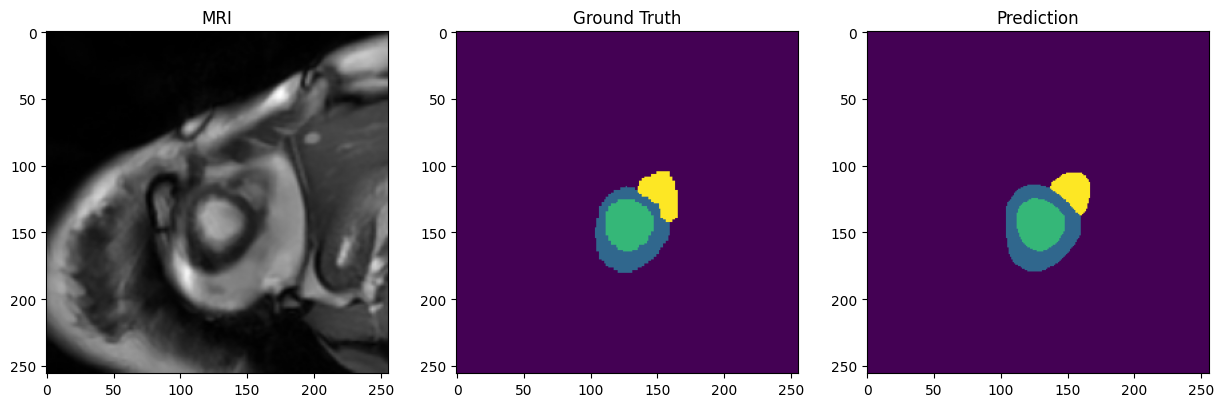

In [7]:
model, dataset = evaluate_model(
    SAX_MODEL,
    ROOT,
    "SAX_TR"
)

visualize_prediction(model, dataset, idx=50)

Using 2 GPUs


Evaluating 2CH_TR: 100%|██████████| 134/134 [02:18<00:00,  1.03s/it]



Results for 2CH_TR
Dice Score : 0.9189
HD95       : 5.1108
ASD        : 1.8299


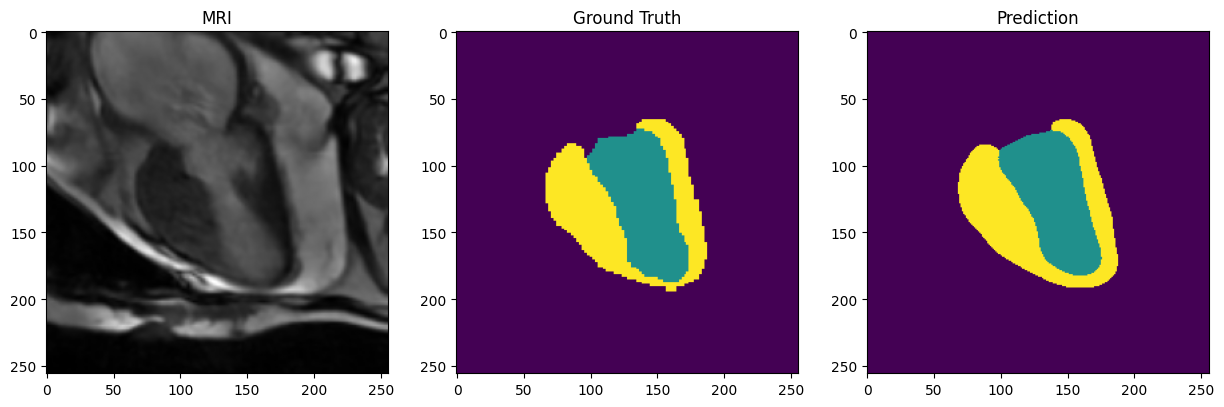

In [8]:
model_2ch, dataset_2ch = evaluate_model(
    CH2_MODEL,
    ROOT,
    "2CH_TR"
)

visualize_prediction(
    model_2ch,
    dataset_2ch,
    idx=50
)

Using 2 GPUs


Evaluating 4CH_TR: 100%|██████████| 130/130 [03:11<00:00,  1.48s/it]



Results for 4CH_TR
Dice Score : 0.9281
HD95       : 3.9646
ASD        : 1.4240


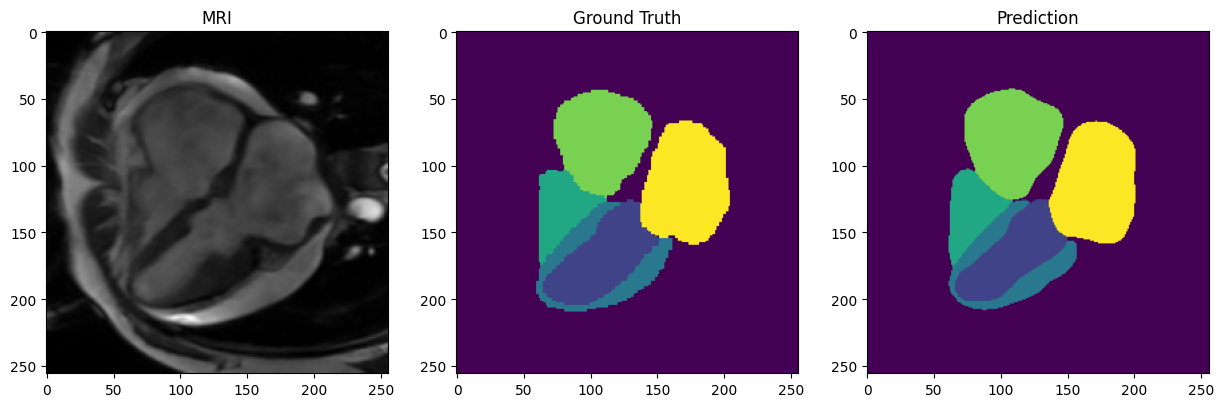

In [9]:
model_4ch, dataset_4ch = evaluate_model(
    CH4_MODEL,
    ROOT,
    "4CH_TR"
)

visualize_prediction(
    model_4ch,
    dataset_4ch,
    idx=50
)

In [10]:
import matplotlib.pyplot as plt

def plot_dice_per_sample(model, dataset, view):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    scores = []

    with torch.no_grad():

        for i in range(len(dataset)):

            img, mask, _ = dataset[i]

            pred = model(
                img.unsqueeze(0).to(device)
            )

            dice = dice_score(
                pred,
                mask.unsqueeze(0).to(device),
                VIEW_CONFIG[view]["num_classes"]
            )

            scores.append(dice.item())

    plt.figure(figsize=(10,5))

    plt.plot(scores)

    plt.xlabel("Sample")
    plt.ylabel("Dice Score")
    plt.title(f"Dice Scores - {view}")

    plt.grid(True)

    plt.show()

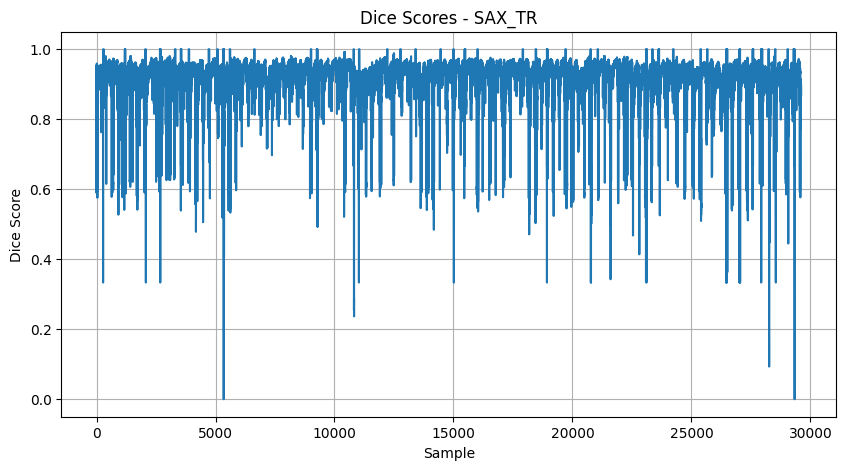

KeyboardInterrupt: 

In [11]:
plot_dice_per_sample(model, dataset, "SAX_TR")
plot_dice_per_sample(model, dataset, "2CH_TR")
plot_dice_per_sample(model, dataset, "4CH_TR")

In [12]:
def plot_area_comparison(model, dataset, view):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    gt_areas = []
    pred_areas = []

    model.eval()

    with torch.no_grad():

        for i in range(len(dataset)):

            img, mask, _ = dataset[i]

            pred = model(
                img.unsqueeze(0).to(device)
            )

            pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

            gt_area = (mask.numpy() > 0).sum()
            pred_area = (pred > 0).sum()

            gt_areas.append(gt_area)
            pred_areas.append(pred_area)

    plt.figure(figsize=(6,6))

    plt.scatter(gt_areas, pred_areas)

    plt.xlabel("Ground Truth Area")
    plt.ylabel("Predicted Area")

    plt.title(f"Area Comparison - {view}")

    plt.grid(True)

    plt.show()

In [15]:
#plot_area_comparison(model, dataset, "SAX_TR")
#plot_area_comparison(model, dataset, "2CH_TR")
plot_area_comparison(model, dataset, "4CH_TR")

KeyboardInterrupt: 

In [ ]:
def plot_dice_histogram(model, dataset, view):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    scores = []

    model.eval()

    with torch.no_grad():

        for i in range(len(dataset)):

            img, mask, _ = dataset[i]

            pred = model(
                img.unsqueeze(0).to(device)
            )

            dice = dice_score(
                pred,
                mask.unsqueeze(0).to(device),
                VIEW_CONFIG[view]["num_classes"]
            )

            scores.append(dice.item())

    plt.figure(figsize=(8,5))

    plt.hist(scores, bins=20)

    plt.xlabel("Dice Score")
    plt.ylabel("Frequency")

    plt.title(f"Dice Distribution - {view}")

    plt.grid(True)

    plt.show()

In [ ]:
plot_dice_histogram(model, dataset, "SAX_TR")
plot_dice_histogram(model, dataset, "2CH_TR")
plot_dice_histogram(model, dataset, "4CH_TR")